In [50]:
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import ToolMessageChunk
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage

import os
load_dotenv()
if os.environ["GOOGLE_API_KEY"]=="" :
    raise ValueError("Please set the GOOGLE_API_KEY environment variable in the .env file.")
else:
    print("GOOGLE_API_KEY is set.")

GOOGLE_API_KEY is set.


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAI
llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # or "gemini-1.0-pro", "gemini-2.0-flash", etc.
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [17]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def test_duckduckgo_search(query: str) -> str:
    """Use this tool to search the web for information."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)


## creating arxiv tool 

In [8]:
from langchain_community.retrievers import ArxivRetriever
from langchain_community.utilities import ArxivAPIWrapper

arxiv_retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
)

arxiv_retriever.invoke("quantum computing")

AttributeError: module 'fitz' has no attribute 'fitz'

## wikipedia tool

In [12]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
wikipedia_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wikipedia_query.invoke("what is langchain?")

'Page: Model Context Protocol\nSummary: The Model Context Protocol (MCP) is an open standard and open-source framework introduced by Anthropic in November 2024 to standardize the way artificial intelligence (AI) systems like large language models (LLMs) integrate and share data with external tools, systems, and data sources. MCP provides a universal interface for reading files, executing functions, and handling contextual prompts. Following its announcement, the protocol was adopted by major AI providers, including OpenAI and Google DeepMind.\n\nPage: Vector database\nSummary: A vector database, vector store or vector search engine is a database that stores and retrieves embeddings of data in vector space. Vector databases typically implement approximate nearest neighbor algorithms so users can search for records semantically similar to a given input, unlike traditional databases which primarily look up records by exact match. Use-cases for vector databases include similarity search, s

## create custom tool

In [14]:
@tool
def personal_info(name: str):
    """Use this tool to get personal information about someone"""
    info = {
        "Alice": "Alice is a software engineer who loves hiking.",
        "Bob": "Bob is a graphic designer who enjoys cooking.",
        "Charlie": "Charlie is a data scientist who is passionate about music."
    }
    return info.get(name, "No information available for this person.")

In [19]:
personal_info.invoke("Alice")


'Alice is a software engineer who loves hiking.'

In [20]:
test_duckduckgo_search.invoke("what is the capital of india?")

"This is a list of locations which have served as capital cities in India. The current capital city is New Delhi, which replaced Calcutta in 1911. What is the Capital of India?of their Indian Empire from Calcutta to Delhi in 1911, they created a new governmental district south of the latter designated as New Delhi; the new capital was not formally inaugurated until 1931. Capital - time difference. India Standard Time (IST) now 9 hours and 30 minutes ahead of New York.New Delhi is the capital of India. Latitude: 28.62. Longitude: 77.21. Republic of India. Abbreviations: IN, IND. Capital: New Delhi. India's administrative divisions of States and Union Territories and their capitals."

## Tool binding

In [22]:
tools = [test_duckduckgo_search, personal_info]
tool_bindings = llm.bind_tools(tools)

In [30]:
response = tool_bindings.invoke("What is the capital of India? ")
response.tool_calls

[{'name': 'test_duckduckgo_search',
  'args': {'query': 'capital of India'},
  'id': 'b9e9216f-523d-41bf-8529-7ee154782c04',
  'type': 'tool_call'}]

### LangGraph Creation

In [34]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages : List

In [63]:
def llm_nodes(state: graph_schema)-> graph_schema:
    messages = state["messages"]
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    ##LLM with tools
    chain = prompt | tool_bindings
    response = chain.invoke({"input": messages})

    state["messages"] = messages + [response]
    return state

## Create Conditional edge function

In [64]:
from langgraph.graph import StateGraph, START, END

def if_tool_call(state: graph_schema)-> str:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return END

In [68]:
# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema)-> graph_schema:
    messages = state["messages"]
    toolsby_name = {tool.name: tool for tool in tools}
    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool = toolsby_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_results.append(observation)
    
    state["messages"] = messages + tool_results
    return state

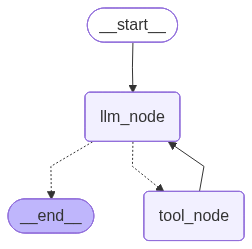

In [71]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)
graph.add_node("llm_node", llm_nodes)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node": "tool_node", END: END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

react_graph = graph.compile()

from IPython.display import Image
Image(react_graph.get_graph().draw_mermaid_png())


## Graph Invocation

In [77]:
react_graph.invoke({"messages": [HumanMessage(content="What is quantum computation? ")]})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 59.240974971s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT